## Part 0: Set-up and EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reading the data
inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

C:\Users\monaa\AppData\Local\Temp\ipykernel_28016\30242840.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


In [2]:
# Dataset size
inventory.shape

(132313, 17)

In [3]:
# dataset columns
inventory.columns.tolist()

['YEAR',
 'CARRIER',
 'CARRIER_NAME',
 'MANUFACTURE_YEAR',
 'UNIQUE_CARRIER_NAME',
 'SERIAL_NUMBER',
 'TAIL_NUMBER',
 'AIRCRAFT_STATUS',
 'OPERATING_STATUS',
 'NUMBER_OF_SEATS',
 'MANUFACTURER',
 'AIRCRAFT_TYPE',
 'MODEL',
 'CAPACITY_IN_POUNDS',
 'ACQUISITION_DATE',
 'AIRLINE_ID',
 'UNIQUE_CARRIER']

In [4]:
# data types
inventory.dtypes

YEAR                     int64
CARRIER                 object
CARRIER_NAME            object
MANUFACTURE_YEAR       float64
UNIQUE_CARRIER_NAME     object
SERIAL_NUMBER           object
TAIL_NUMBER             object
AIRCRAFT_STATUS         object
OPERATING_STATUS        object
NUMBER_OF_SEATS        float64
MANUFACTURER            object
AIRCRAFT_TYPE           object
MODEL                   object
CAPACITY_IN_POUNDS     float64
ACQUISITION_DATE        object
AIRLINE_ID             float64
UNIQUE_CARRIER          object
dtype: object

In [5]:
# first 5 rows
inventory.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16


## Part 1: Missing Data Investigation

In [6]:
# number of missing values per column
print(inventory.isnull().sum())

YEAR                       0
CARRIER                   49
CARRIER_NAME             105
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS        13238
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS     13332
ACQUISITION_DATE         967
AIRLINE_ID               105
UNIQUE_CARRIER           164
dtype: int64


In [7]:
# missing values percent per col
print((inventory.isnull().sum()/ len(inventory)*100).round(2))

YEAR                    0.00
CARRIER                 0.04
CARRIER_NAME            0.08
MANUFACTURE_YEAR        0.00
UNIQUE_CARRIER_NAME     0.08
SERIAL_NUMBER           0.00
TAIL_NUMBER             0.00
AIRCRAFT_STATUS         0.00
OPERATING_STATUS        0.00
NUMBER_OF_SEATS        10.01
MANUFACTURER            0.00
AIRCRAFT_TYPE          22.62
MODEL                   0.01
CAPACITY_IN_POUNDS     10.08
ACQUISITION_DATE        0.73
AIRLINE_ID              0.08
UNIQUE_CARRIER          0.12
dtype: float64


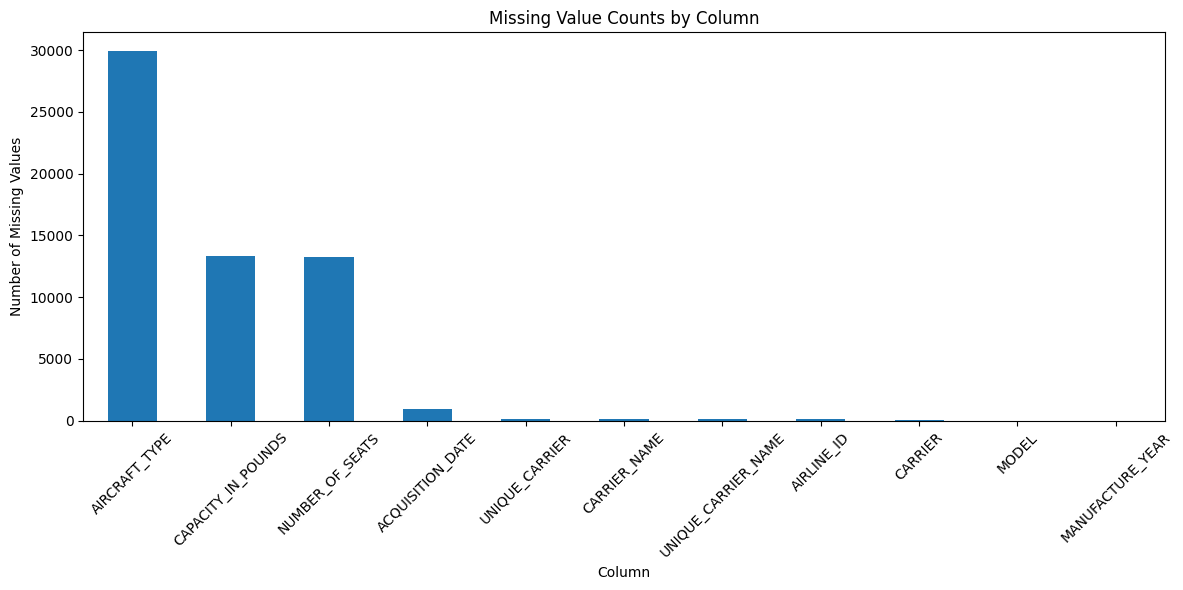

In [8]:
# Plot to visualize missing data counts across all columns 

missing = inventory.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar')
plt.title('Missing Value Counts by Column')
plt.ylabel('Number of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Investigating `CARRIER` and `UNIQUE_CARRIER` Missing Values

In [9]:
# Check which airlines have missing carrier codes
inventory[inventory['CARRIER'].isnull()][['CARRIER', 'UNIQUE_CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER_NAME']].head(20)

,CARRIER,UNIQUE_CARRIER,CARRIER_NAME,UNIQUE_CARRIER_NAME
11776,NaN,NaN,North American Airlines,North American Airlines
11777,NaN,NaN,North American Airlines,North American Airlines
11778,NaN,NaN,North American Airlines,North American Airlines
11779,NaN,NaN,North American Airlines,North American Airlines
11780,NaN,NaN,North American Airlines,North American Airlines
11781,NaN,NaN,North American Airlines,North American Airlines
11782,NaN,NaN,North American Airlines,North American Airlines
11783,NaN,NaN,North American Airlines,North American Airlines
11784,NaN,NaN,North American Airlines,North American Airlines
11785,NaN,NaN,North American Airlines,North American Airlines


In [10]:
# Check if North American Airlines have a carrier code anywhere in the dataset
inventory[inventory['CARRIER_NAME'] == 'North American Airlines'][['CARRIER', 'UNIQUE_CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates()

,CARRIER,UNIQUE_CARRIER,CARRIER_NAME,AIRLINE_ID
11776,NaN,NaN,North American Airlines,20415.0
26207,NA,NaN,North American Airlines,20415.0


### `CARRIER` Imputation Function

In [11]:
def impute_carrier(df):
    mask = (df['CARRIER_NAME'] == 'North American Airlines') & (df['CARRIER'].isnull())
    df.loc[mask, 'CARRIER'] = 'NA'
    df.loc[mask, 'UNIQUE_CARRIER'] = 'NA'
    return df

inventory = impute_carrier(inventory)

print(inventory['CARRIER'].isnull().sum())   
print(inventory['UNIQUE_CARRIER'].isnull().sum()) 

0
115


### Investigating `CARRIER_NAME` and `AIRLINE_ID` Missing Values

In [12]:
# Check rows with missing CARRIER_NAME
inventory[inventory['CARRIER_NAME'].isnull()][['CARRIER', 'UNIQUE_CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER_NAME', 'AIRLINE_ID']].head(20)

,CARRIER,UNIQUE_CARRIER,CARRIER_NAME,UNIQUE_CARRIER_NAME,AIRLINE_ID
11465,L4,NaN,NaN,NaN,NaN
11466,L4,NaN,NaN,NaN,NaN
11467,L4,NaN,NaN,NaN,NaN
11468,L4,NaN,NaN,NaN,NaN
11469,L4,NaN,NaN,NaN,NaN
11470,L4,NaN,NaN,NaN,NaN
11471,L4,NaN,NaN,NaN,NaN
11472,L4,NaN,NaN,NaN,NaN
54610,OH,NaN,NaN,NaN,NaN
54611,OH,NaN,NaN,NaN,NaN


In [13]:
# Check missing AIRLINE_ID
print("Missing AIRLINE_ID:", inventory['AIRLINE_ID'].isnull().sum())

Missing AIRLINE_ID: 105


In [14]:
# Check if rows missing CARRIER_NAME and AIRLINE_ID are the same
print("Missing both AIRLINE_ID and CARRIER_NAME:", (inventory['AIRLINE_ID'].isnull() & inventory['CARRIER_NAME'].isnull()).sum())

Missing both AIRLINE_ID and CARRIER_NAME: 105


In [15]:
# Check if carrier names are filled in for OH and L4 anywhere in the dataset
inventory[inventory['CARRIER'].isin(['L4', 'OH'])][['CARRIER', 'UNIQUE_CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates()

,CARRIER,UNIQUE_CARRIER,CARRIER_NAME,AIRLINE_ID
4896,OH,OH,Comair Inc.,20417.0
11465,L4,NaN,NaN,NaN
18739,L4,L3,Lynx Aviation d/b/a Frontier Airlines,21217.0
33726,OH,OH (1),Comair Inc.,20417.0
54610,OH,NaN,NaN,NaN
68915,OH,OH,PSA Airlines Inc.,20397.0


In [16]:
# Check how many rows have CARRIER_NAME and UNIQUE_CARRIER missing
mask = inventory['CARRIER_NAME'].isnull() & inventory['UNIQUE_CARRIER'].isnull()
print(mask.sum())

105


### Investigating `MANUFACTURE_YEAR` Missing Values

In [17]:
# Check rows with missing manufacture year
inventory[inventory['MANUFACTURE_YEAR'].isnull()][['CARRIER_NAME', 'MANUFACTURE_YEAR', 'SERIAL_NUMBER', 'TAIL_NUMBER', 'MODEL']]

,CARRIER_NAME,MANUFACTURE_YEAR,SERIAL_NUMBER,TAIL_NUMBER,MODEL
116651,Atlas Air Inc.,NaN,26259,N664GT,B747-400
124680,Endeavor Air Inc.,NaN,10134,N655CA,CL-600-2C10
124681,Endeavor Air Inc.,NaN,10182,N690CA,CL-600-2C10


In [18]:
# Check if the same tail numbers appear with a present manufacture year somewhere else in the dataset
tail_numbers = ['N664GT', 'N655CA', 'N690CA']

inventory[inventory['TAIL_NUMBER'].isin(tail_numbers)][['TAIL_NUMBER', 'MANUFACTURE_YEAR', 'MODEL', 'YEAR']].drop_duplicates()

,TAIL_NUMBER,MANUFACTURE_YEAR,MODEL,YEAR
5056,N655CA,2004.0,RJ-700,2006
5062,N690CA,2004.0,RJ-700,2006
12379,N655CA,2004.0,RJ-700,2007
12383,N690CA,2004.0,RJ-700,2007
19529,N655CA,2004.0,RJ-700,2008
19533,N690CA,2004.0,RJ-700,2008
33808,N655CA,2004.0,CRJ700-Passanger,2010
33812,N690CA,2004.0,CRJ700-Passanger,2010
40846,N655CA,2004.0,CRJ700-Passanger,2011
40850,N690CA,2004.0,CRJ700-Passanger,2011


### Imputation function for missing `MANUFACTURE_YEAR` Rows

In [19]:
def impute_manufacture_year(df):
    # N655CA and N690CA consistently show 2004 in all other years
    # N664GT cannot be imputed
    df.loc[df['TAIL_NUMBER'] == 'N655CA', 'MANUFACTURE_YEAR'] = df.loc[df['TAIL_NUMBER'] == 'N655CA', 'MANUFACTURE_YEAR'].fillna(2004.0)
    df.loc[df['TAIL_NUMBER'] == 'N690CA', 'MANUFACTURE_YEAR'] = df.loc[df['TAIL_NUMBER'] == 'N690CA', 'MANUFACTURE_YEAR'].fillna(2004.0)
    return df

inventory = impute_manufacture_year(inventory)

# Verify only one row now has a missing manufacture year
print(inventory['MANUFACTURE_YEAR'].isnull().sum())

1


### Investigating Missing `NUMBER_OF_SEATS` and `CAPACITY_IN_POUNDS`

In [20]:
# Check if the two columns are missing together
both_missing = inventory['NUMBER_OF_SEATS'].isnull() & inventory['CAPACITY_IN_POUNDS'].isnull()
only_seats = inventory['NUMBER_OF_SEATS'].isnull() & inventory['CAPACITY_IN_POUNDS'].notnull()
only_capacity = inventory['CAPACITY_IN_POUNDS'].isnull() & inventory['NUMBER_OF_SEATS'].notnull()

print("Both missing:", both_missing.sum())
print("Only number of seats missing:", only_seats.sum())
print("Only Capacity in pounds missing:", only_capacity.sum())

Both missing: 1808
Only number of seats missing: 11430
Only Capacity in pounds missing: 11524


In [21]:
# Check if aircraft type is related to missing number of seats
print("AIRCRAFT_TYPE (missing NUMBER_OF_SEATS)")
print(inventory[inventory['NUMBER_OF_SEATS'].isnull()]['AIRCRAFT_TYPE'].value_counts().head(10))

# Check if aircraft type is related to missing capacity in pounds
print("AIRCRAFT_TYPE (missingC APACITY_IN_POUNDS)")
print(inventory[inventory['CAPACITY_IN_POUNDS'].isnull()]['AIRCRAFT_TYPE'].value_counts().head(10))



AIRCRAFT_TYPE (missing NUMBER_OF_SEATS)
AIRCRAFT_TYPE
6261.0    1639
6271.0    1191
6991      1041
6271       598
6261       471
6991       465
6961.0     436
6241.0     380
6221       374
6231.0     349
Name: count, dtype: int64
AIRCRAFT_TYPE (missingC APACITY_IN_POUNDS)
AIRCRAFT_TYPE
6141    1140
6941     759
8881     682
6991     602
6121     587
6731     550
6981     502
4162     492
6262     463
6381     380
Name: count, dtype: int64


In [22]:
# Check overall distribution of aircraft types
print(inventory['AIRCRAFT_TYPE'].value_counts())

AIRCRAFT_TYPE
6141.0    6059
6121.0    5117
6941.0    4611
6291.0    4271
6141      3619
          ... 
6681         1
7151         1
4803         1
7303.0       1
3203.0       1
Name: count, Length: 324, dtype: int64


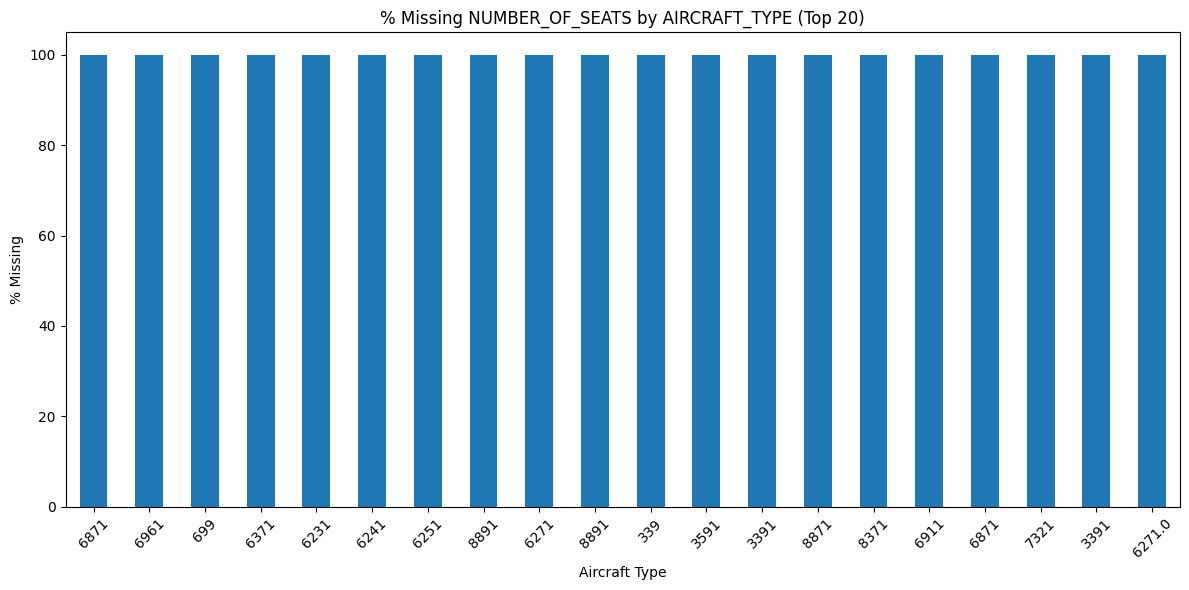

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot missing seats data pattern for aircraft type
missing_by_aircraft_type = inventory.groupby('AIRCRAFT_TYPE')['NUMBER_OF_SEATS'].apply(
    lambda x: x.isnull().mean() * 100
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
missing_by_aircraft_type.plot(kind='bar')
plt.title('% Missing NUMBER_OF_SEATS by AIRCRAFT_TYPE (Top 20)')
plt.ylabel('% Missing')
plt.xlabel('Aircraft Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

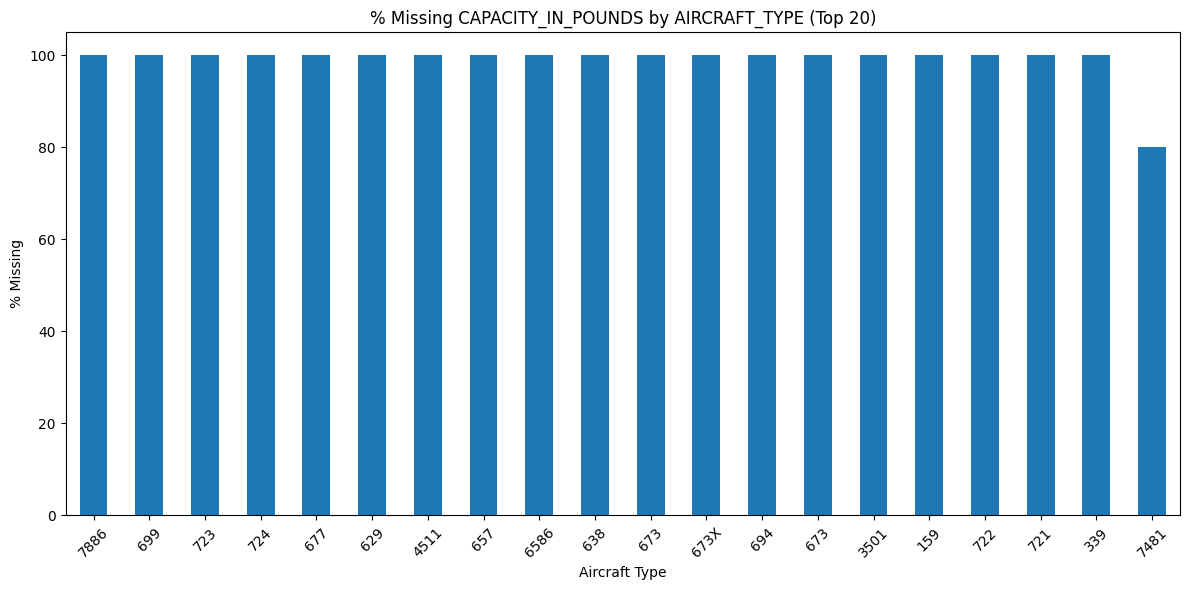

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot missing capacity data pattern for aircraft type
missing_by_aircraft_type = inventory.groupby('AIRCRAFT_TYPE')['CAPACITY_IN_POUNDS'].apply(
    lambda x: x.isnull().mean() * 100
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
missing_by_aircraft_type.plot(kind='bar')
plt.title('% Missing CAPACITY_IN_POUNDS by AIRCRAFT_TYPE (Top 20)')
plt.ylabel('% Missing')
plt.xlabel('Aircraft Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Check median number of seats per model
print("Median NUMBER_OF_SEATS per MODEL:")
print(inventory.groupby('MODEL')['NUMBER_OF_SEATS'].median().dropna().head(20))

Median NUMBER_OF_SEATS per MODEL:
MODEL
0                0.0
150              7.0
200              9.0
2012             0.0
208B             0.0
318-111        120.0
319-111        136.0
319-112        150.0
320-112        162.0
320-114        174.0
320-211        186.0
320-211N       186.0
320-214        180.0
320-251        186.0
320-251N       186.0
321-211        180.0
340bPSGR        34.0
382G-44K-30      0.0
408              0.0
450             13.0
Name: NUMBER_OF_SEATS, dtype: float64


In [26]:
# Check median capacity in pounds per model
print("Median CAPACITY_IN_POUNDS per MODEL:")
print(inventory.groupby('MODEL')['CAPACITY_IN_POUNDS'].median().dropna().head(20))

Median CAPACITY_IN_POUNDS per MODEL:
MODEL
0            19700.0
150          26100.0
200          35450.0
2012            12.0
318-111     130100.0
319-111     141100.0
319-112     141100.0
320-112     162000.0
320-114     162000.0
320-211     162000.0
320-211N    162000.0
320-214     162000.0
320-251     162000.0
320-251N    162000.0
321-211     206000.0
340bPSGR     29000.0
450          73900.0
550          91000.0
560XL        20200.0
600           5241.5
Name: CAPACITY_IN_POUNDS, dtype: float64


In [27]:
# Check if there is a model for all the missing seats
missing_seats = inventory['NUMBER_OF_SEATS'].isnull()
has_model = inventory['MODEL'].notnull()

print("Missing seats, with model:", (missing_seats & has_model).sum())
print("Missing seats, no model:", (missing_seats & ~has_model).sum())

# Check if there is a model for all missing capacities
missing_capacity = inventory['CAPACITY_IN_POUNDS'].isnull()
has_model = inventory['MODEL'].notnull()

print("Missing capacity, with a model:", (missing_capacity & has_model).sum())
print("Missing capacity, no model:", (missing_capacity & ~has_model).sum())

Missing seats, with model: 13238
Missing seats, no model: 0
Missing capacity, with a model: 13332
Missing capacity, no model: 0


### Imputation for `NUMBER_OF_SEATS` AND `CAPACITY_IN_POUNDS`

In [28]:
def impute_seats_and_capacity(df):
    # Missingness for both cols is MAR in relation to AIRCRAFT_TYPE
    # I imputed using the median value per model for all the missing rows
    # with models that have capacity/seats data in the dataset. 
    median_seats = df.groupby('MODEL')['NUMBER_OF_SEATS'].transform('median')
    median_capacity = df.groupby('MODEL')['CAPACITY_IN_POUNDS'].transform('median')
    
    df['NUMBER_OF_SEATS'] = df['NUMBER_OF_SEATS'].fillna(median_seats)
    df['CAPACITY_IN_POUNDS'] = df['CAPACITY_IN_POUNDS'].fillna(median_capacity)
    
    return df

inventory = impute_seats_and_capacity(inventory)

# Check how many missing values remained
print("Remaining missing NUMBER_OF_SEATS:", inventory['NUMBER_OF_SEATS'].isnull().sum())
print("Remaining missing CAPACITY_IN_POUNDS:", inventory['CAPACITY_IN_POUNDS'].isnull().sum())

Remaining missing NUMBER_OF_SEATS: 8399
Remaining missing CAPACITY_IN_POUNDS: 5949


In [29]:
# For future work, models whose capacity/seats data needs to be externally looked up
models_no_seats = inventory.groupby('MODEL')['NUMBER_OF_SEATS'].median()
print("Models with no seats data:", models_no_seats[models_no_seats.isnull()].index.tolist())

models_no_capacity = inventory.groupby('MODEL')['CAPACITY_IN_POUNDS'].median()
print("Models with no capacity data:", models_no_capacity[models_no_capacity.isnull()].index.tolist())

Models with no seats data: ['321-271NX', '747-400-PSGR', '747-451', '757-251', '757-26D', '757-300', '757-300-PSGR', '757-324', '757-33N', '757-351', '757-351-PSGR', '767-224', '767-300-PSGR', '767-300ER', '767-300ER-PSGR', '767-322', '767-324ER-PSGR', '767-328', '767-332-PSGR', '767-332ER-PSGR', '767-3CB', '767-3P6ER-PSGR', '767-3Q8', '767-400ER', '767-400ER-PSGR', '767-424ER', '767-432ER', '767-432ER-PSGR', '777-200', '777-200-PSGR', '777-222', '777-223', '777-224', '777-232ER-PSGR', '777-232LR', '777-232LR-PSGR', '777-2U8', '777-300ER', '777-323ER', '787-10', '787-8', '787-9', 'A-321-PSGR', 'A300-600PASSENGER', 'A300-600RPASSENGER', 'A321-200NEO-PSGR', 'A321-213', 'A321PAX', 'A330', 'A330-2', 'A330-200', 'A330-200            ', 'A330-223', 'A330-223-PSGR', 'A330-243', 'A330-3', 'A330-300            ', 'A330-302', 'A330-302-PSGR', 'A330-323', 'A330-323-PSGR', 'A330-323X', 'A330-343', 'A330-941', 'A330-941-PSGR', 'A330-PSGR', 'A3300200', 'A350-900-PSGR', 'A350-941', 'A350-941-PSGR', '

## Part 2: Standardization and Transformation

### Inspecting `AIRCRAFT_STATUS` and `OPERARING_STATUS`

In [30]:
# Check unique values for both cols
print("Aircraft status unique values:")
print(inventory['AIRCRAFT_STATUS'].value_counts())

print("Operating status unique values:")
print(inventory['OPERATING_STATUS'].value_counts())

Aircraft status unique values:
AIRCRAFT_STATUS
O    79487
b    30852
B    12699
a     7804
A     1330
L      122
o       19
Name: count, dtype: int64
Operating status unique values:
OPERATING_STATUS
Y    126577
N      5664
y        71
          1
Name: count, dtype: int64


### Standardization functions for `AIRCRAFT_STATUS` and `OPERATING_STATUS`

In [31]:
def standardize_status_columns(df):
    # Standardize capitalization and remove whitespace
    # Replace remaining empty rows with NA
    df['AIRCRAFT_STATUS'] = df['AIRCRAFT_STATUS'].str.upper().str.strip()
    df['OPERATING_STATUS'] = df['OPERATING_STATUS'].str.upper().str.strip()
    df['OPERATING_STATUS'] = df['OPERATING_STATUS'].replace('', pd.NA)
    return df

inventory = standardize_status_columns(inventory)

# Verify
print(inventory['AIRCRAFT_STATUS'].value_counts())
print(inventory['OPERATING_STATUS'].value_counts())

AIRCRAFT_STATUS
O    79506
B    43551
A     9134
L      122
Name: count, dtype: int64
OPERATING_STATUS
Y    126648
N      5664
Name: count, dtype: int64


### Inspecting `MANUFACTURER` values

In [32]:
print(inventory['MANUFACTURER'].value_counts().to_string())

MANUFACTURER
BOEING                                                                              15922
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                                                                               41

### Standardization function for common `MANUFACTURER` values

In [ ]:
def standardize_manufacturer(df):
    df['MANUFACTURER'] = df['MANUFACTURER'].str.strip().str.upper()
    
    # Boeing
    boeing_names = ['THEBOEINGCO', 'BOEINGCO', 'BOEINGCOMPANY', 'THEBOEINGCOMPANY', 
                       'BOEING(MCDONNELL-DOUGLAS)', 'BOEING747-446', 'B757-223',
                       'BOEINGCO.']
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(boeing_names, 'BOEING')
    
    # Airbus
    airbus_names = ['AIRBUSINDUSTRIES', 'AIRBUSINDUSTRIE', 'AIRBUSCOMPANY', 'AIRBUS']
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(airbus_names, 'AIRBUS')
    
    # McDonnell Douglas
    mcd_names = ['MCDONNELLDOUGLAS', 'MCDONNELL-DOUGLAS', 'MCDONNELDOUGLAS',
                    'MCDONNELLDOUGLASMD11-F', 'MDDOUGLAS', 'MCDONNELLDOUG',
                    'MCDO', 'MCDONNELL', 'MCDONNEL', 'MCDONALD DOUGLAS']
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(mcd_names, 'MCDONNELL DOUGLAS')
    
    # Saab
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(['SAAB AIRCRAFT', 'SAABFAIRCHILD', 
                                                      'SAAB-FAIRCHILD', 'SAABSCANIA'], 'SAAB')
    
    # Dassault 
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(['DASSULT SUD', 'DASSAULT/SUD'], 'DASSAULT')
    
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(['BOMBARDIER', 'BOMBARDIERAEROSPACE'], 'BOMBARDIER')
    
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(['DOUGLAS', 'DOUGLASAIRCRAFT'], 'DOUGLAS')
    
    return df

inventory = standardize_manufacturer(inventory)
print(inventory['MANUFACTURER'].value_counts().head(20))

MANUFACTURER
BOEING               55640
AIRBUS               23513
EMBRAER              15554
BOMBARDIER           12483
MCDONNELL DOUGLAS     9351
CESSNA                4514
CANADAIR              3861
DOUGLAS               1442
ATR                   1181
GE                    1110
DEHAVILLAND           1084
SAAB                   600
GULFSTREAM             441
CONVAIR                208
DASSAULT               182
LOCKHEED               158
DORNIER                100
CURTISS                 46
EASYJET/GOAL            44
CEBUPACIFIC             43
Name: count, dtype: int64


### Inspecting `MODEL` values

In [34]:
print(f"Total unique model values: {inventory['MODEL'].nunique()}")

Total unique model values: 1340


In [35]:
print(inventory['MODEL'].value_counts().to_string())

MODEL
EMB-145                 2614
B-737-7H4               2470
B737-823                2370
A320-232                2333
A321-231                2259
737-700PASSENGERONLY    2027
C-208B                  1872
B757-2                  1775
CRJ-2/4                 1761
B737-800PAX             1621
MD-80                   1610
ERJ-170-200LR           1379
757-200                 1345
CRJ200-2B19             1342
A319                    1267
B-737-8H4               1256
CRJ-200                 1148
ERJ-175                 1132
SUPER80PASSENGER        1108
A320-1/2                1107
757-24APF               1039
B737-3                  1036
MD-88-PSGR              1028
C-208B/3                1017
MD-11                    991
757-232-PSGR             988
CRJ-900LR-PSGR           976
B737-823PASSENGER        956
B737-8                   951
B737-7/L                 929
CRJ-700                  880
737-832-PSGR             877
CRJ-200-PSGR             861
A319-112                 856
B737-900

In [36]:
def standardize_model(df):
    model = df['MODEL'].str.strip().str.upper()
    
    # Remove suffixes
    suffixes = ['-PSGR', 'PSGR', '-PAX', 'PAX', '-PASSENGER', 'PASSENGER',
                'PASSENGERONLY', 'ALLPAX', '-ALLPAX', 'ALLPASSENGER']
    for suffix in suffixes:
        model = model.str.replace(suffix, '', regex=False)
    
    # Standardize Boeing 737 
    model = model.str.replace(r'^B-737-', '737-', regex=True)
    model = model.str.replace(r'^B737-', '737-', regex=True)
    
    # Standardize more Boeing models
    for series in ['757', '767', '777', '747', '717', '727', '787']:
        model = model.str.replace(f'^B-{series}-', f'{series}-', regex=True)
        model = model.str.replace(f'^B{series}-', f'{series}-', regex=True)
    
    model = model.str.strip()
    
    df['MODEL'] = model
    return df

inventory = standardize_model(inventory)

print(f"Unique models after cleaning: {inventory['MODEL'].nunique()}")
print(inventory['MODEL'].value_counts().head(20))

Unique models after cleaning: 1002
MODEL
737-823          3603
737-7H4          3043
EMB-145          2976
A320-232         2463
757-2            2369
A321-231         2298
757-200          2210
737-800          2171
737-700ONLY      2027
CRJ-200          2009
737-8            1999
C-208B           1872
CRJ-2/4          1761
737-900ER        1674
MD-80            1611
SUPER80          1589
737-8H4          1512
A320-1/2         1466
ERJ-170-200LR    1379
A319             1378
Name: count, dtype: int64


## Part 3: Removing Rows with Missing Data

In [37]:
cols_to_check = ['CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID','OPERATING_STATUS']

before = len(inventory)
inventory_clean = inventory.dropna(subset=cols_to_check).copy()
after = len(inventory_clean)

print(f"Rows before dropping: {before}")
print(f"Rows after dropping: {after}")
print(f"Rows removed: {before - after}")
print(f"Data remaining: {after/before*100:.2f}%")

Rows before dropping: 132313
Rows after dropping: 118684
Rows removed: 13629
Data remaining: 89.70%


In [38]:
# Check amount of missing values in the columns investigated
inventory_clean.isnull().sum()

YEAR                       0
CARRIER                    0
CARRIER_NAME               0
MANUFACTURE_YEAR           0
UNIQUE_CARRIER_NAME        0
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            0
MANUFACTURER               0
AIRCRAFT_TYPE          28970
MODEL                     11
CAPACITY_IN_POUNDS         0
ACQUISITION_DATE         820
AIRLINE_ID                 0
UNIQUE_CARRIER             0
dtype: int64

## Part 4: Transformation and Derivative Variables

In [39]:
from scipy import stats

# Check skewness for number of seats and capacity in pounds
print("Skewness of NUMBER_OF_SEATS:", inventory_clean['NUMBER_OF_SEATS'].skew())
print("Skewness of CAPACITY_IN_POUNDS:", inventory_clean['CAPACITY_IN_POUNDS'].skew())

Skewness of NUMBER_OF_SEATS: -0.19053753487884748
Skewness of CAPACITY_IN_POUNDS: 2.170504367390384


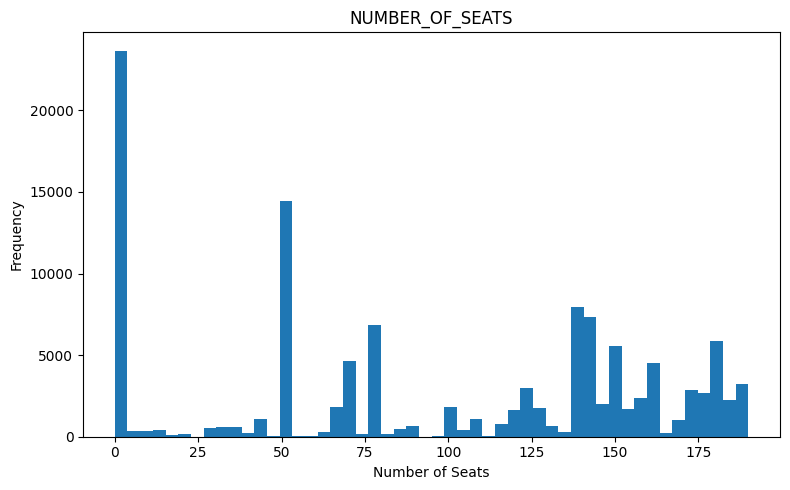

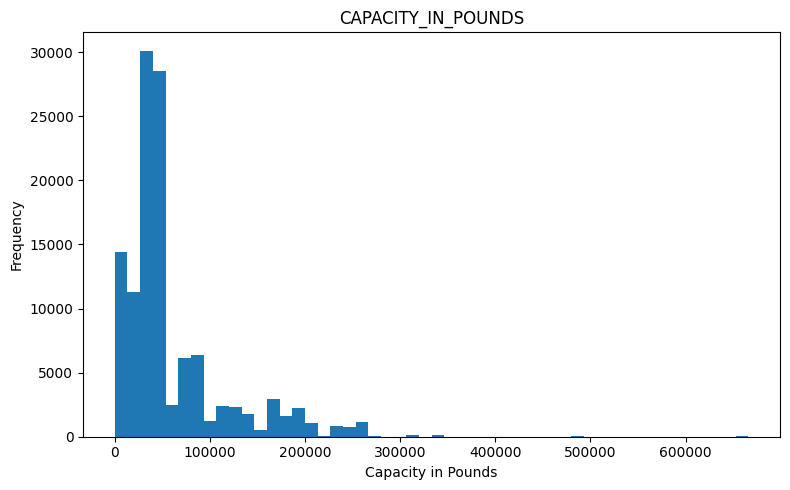

In [40]:
# Plot histograms for both
plt.figure(figsize=(8, 5))
plt.hist(inventory_clean['NUMBER_OF_SEATS'], bins=50)
plt.title('NUMBER_OF_SEATS')
plt.xlabel('Number of Seats')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(inventory_clean['CAPACITY_IN_POUNDS'], bins=50)
plt.title('CAPACITY_IN_POUNDS')
plt.xlabel('Capacity in Pounds')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [41]:
# Check for 0s before applying Box-Cox
print("Min NUMBER_OF_SEATS:", inventory_clean['NUMBER_OF_SEATS'].min())
print("Min CAPACITY_IN_POUNDS:", inventory_clean['CAPACITY_IN_POUNDS'].min())

Min NUMBER_OF_SEATS: 0.0
Min CAPACITY_IN_POUNDS: 0.0


In [42]:
from scipy.stats import boxcox

def apply_boxcox(df):
    # Add 1 to make all values non-zero
    seats_transformed, lambda_seats = boxcox(df['NUMBER_OF_SEATS'] + 1)
    capacity_transformed, lambda_capacity = boxcox(df['CAPACITY_IN_POUNDS'] + 1)
    
    df['NUMBER_OF_SEATS_BOXCOX'] = seats_transformed
    df['CAPACITY_IN_POUNDS_BOXCOX'] = capacity_transformed
    
    print(f"Box-Cox lambda for NUMBER_OF_SEATS: {lambda_seats}")
    print(f"Box-Cox lambda for CAPACITY_IN_POUNDS: {lambda_capacity}")
    
    return df

inventory_clean = apply_boxcox(inventory_clean)

Box-Cox lambda for NUMBER_OF_SEATS: 0.576189317754559
Box-Cox lambda for CAPACITY_IN_POUNDS: 0.34784359695645567


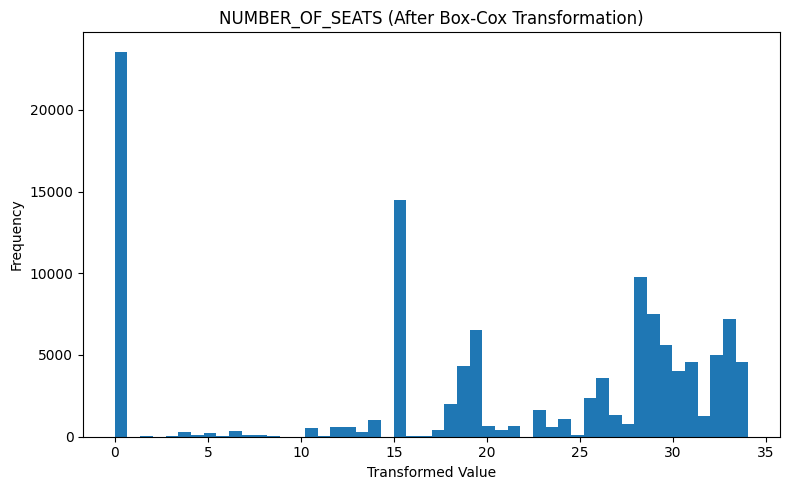

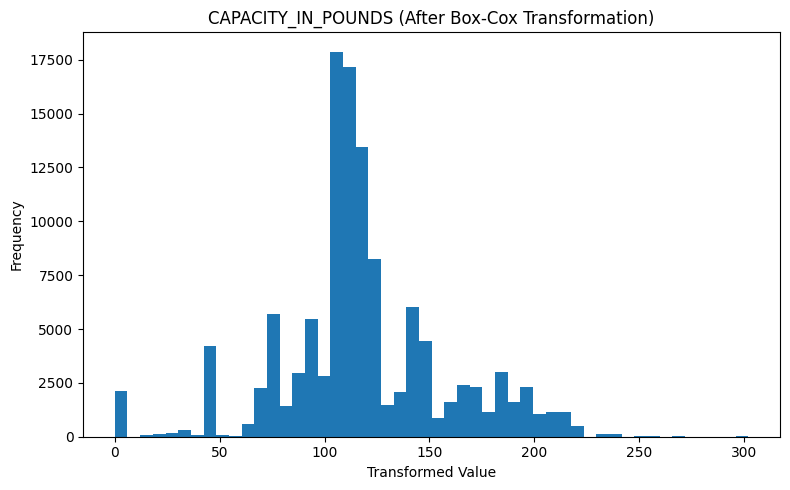

In [43]:
# Plot histograms post-Box Cox transformation
plt.figure(figsize=(8, 5))
plt.hist(inventory_clean['NUMBER_OF_SEATS_BOXCOX'], bins=50)
plt.title('NUMBER_OF_SEATS (After Box-Cox Transformation)')
plt.xlabel('Transformed Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(inventory_clean['CAPACITY_IN_POUNDS_BOXCOX'], bins=50)
plt.title('CAPACITY_IN_POUNDS (After Box-Cox Transformation)')
plt.xlabel('Transformed Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [44]:
# Check skewness of transformed variables
print("Skewness of NUMBER_OF_SEATS (after Box-Cox):", inventory_clean['NUMBER_OF_SEATS_BOXCOX'].skew())
print("Skewness of CAPACITY_IN_POUNDS (after Box-Cox):", inventory_clean['CAPACITY_IN_POUNDS_BOXCOX'].skew())

Skewness of NUMBER_OF_SEATS (after Box-Cox): -0.6386667714146816
Skewness of CAPACITY_IN_POUNDS (after Box-Cox): 0.09728455524296138


## Part 5: Feature Engineering

In [45]:
def create_size_column(df):
    q25 = df['NUMBER_OF_SEATS'].quantile(0.25)
    q50 = df['NUMBER_OF_SEATS'].quantile(0.50)
    q75 = df['NUMBER_OF_SEATS'].quantile(0.75)
    
    print(f"25th percentile: {q25}")
    print(f"50th percentile: {q50}")
    print(f"75th percentile: {q75}")
    
    df['SIZE'] = pd.cut(df['NUMBER_OF_SEATS'],
                        bins=[-1, q25, q50, q75, float('inf')],
                        labels=['SMALL', 'MEDIUM', 'LARGE', 'XLARGE'])
    return df

inventory_clean = create_size_column(inventory_clean)

print(inventory_clean['SIZE'].value_counts())

25th percentile: 50.0
50th percentile: 102.0
75th percentile: 150.0
SIZE
SMALL     42546
LARGE     32451
XLARGE    26689
MEDIUM    16998
Name: count, dtype: int64


### Plots for `SIZE` based on `OPERATING_STATUS`

OPERATING_STATUS         N         Y
SIZE                                
SMALL             0.059935  0.940065
MEDIUM            0.042064  0.957936
LARGE             0.043296  0.956704
XLARGE            0.027502  0.972498


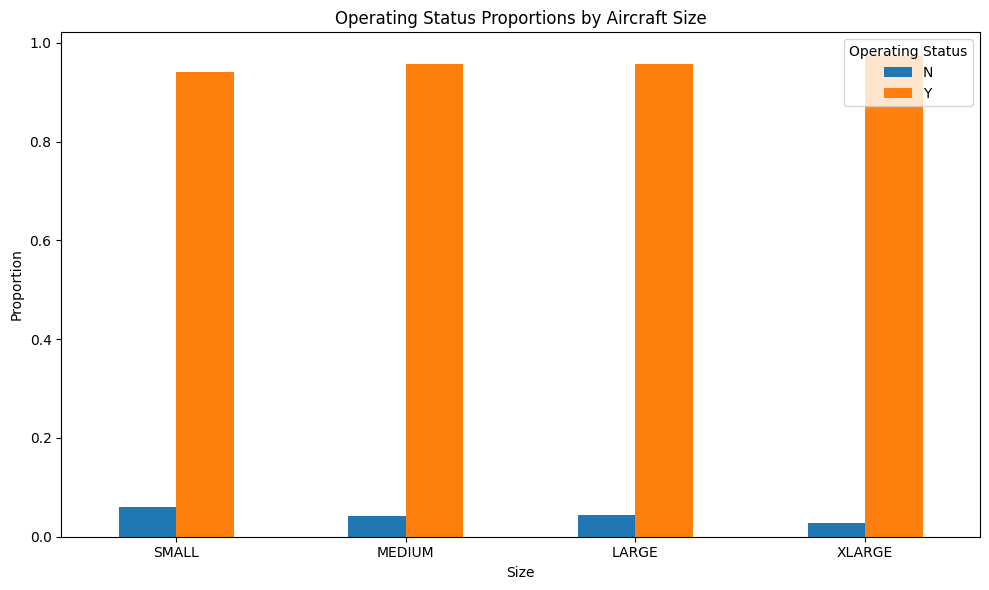

In [46]:
operating_props = inventory_clean.groupby('SIZE', observed=True)['OPERATING_STATUS'].value_counts(normalize=True).unstack()
print(operating_props)

operating_props.plot(kind='bar', figsize=(10, 6))
plt.title('Operating Status Proportions by Aircraft Size')
plt.xlabel('Size')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Operating Status')
plt.tight_layout()
plt.show()

### Plots for `SIZE` based on `AIRCRAFT_STATUS`

AIRCRAFT_STATUS         A         B         L         O
SIZE                                                   
SMALL            0.036666  0.412965       NaN  0.550369
MEDIUM           0.021297  0.454465       NaN  0.524238
LARGE            0.122955  0.288034  0.001202  0.587809
XLARGE           0.085091  0.263367       NaN  0.651542


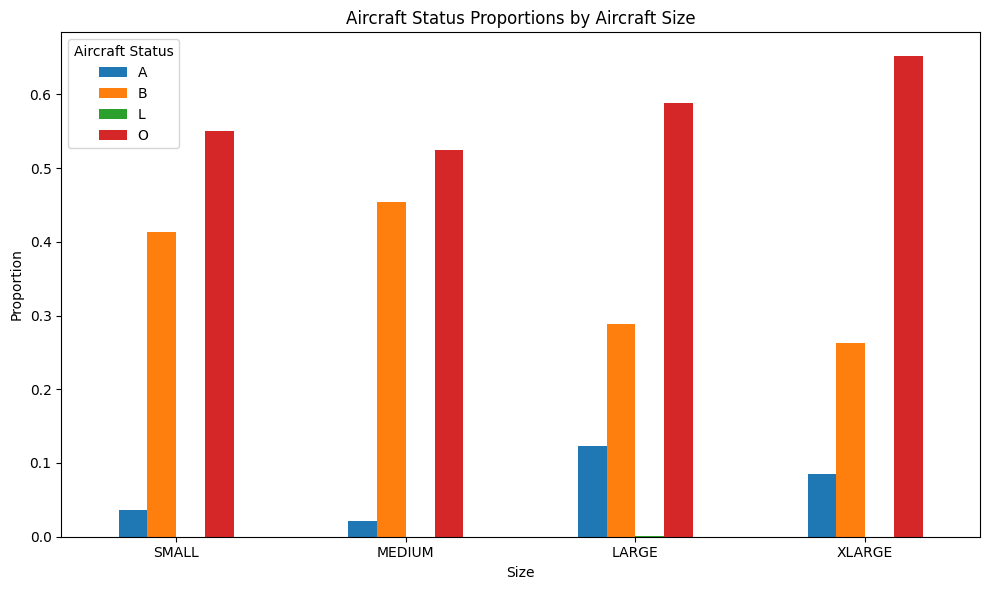

In [47]:
aircraft_props = inventory_clean.groupby('SIZE', observed=True)['AIRCRAFT_STATUS'].value_counts(normalize=True).unstack()
print(aircraft_props)

aircraft_props.plot(kind='bar', figsize=(10, 6))
plt.title('Aircraft Status Proportions by Aircraft Size')
plt.xlabel('Size')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Aircraft Status')
plt.tight_layout()
plt.show()

## Part 6: Modeling Refresher

In [48]:
# Check datatypes before modeling
print(inventory_clean.dtypes)
print(inventory_clean.head())

YEAR                            int64
CARRIER                        object
CARRIER_NAME                   object
MANUFACTURE_YEAR              float64
UNIQUE_CARRIER_NAME            object
SERIAL_NUMBER                  object
TAIL_NUMBER                    object
AIRCRAFT_STATUS                object
OPERATING_STATUS               object
NUMBER_OF_SEATS               float64
MANUFACTURER                   object
AIRCRAFT_TYPE                  object
MODEL                          object
CAPACITY_IN_POUNDS            float64
ACQUISITION_DATE               object
AIRLINE_ID                    float64
UNIQUE_CARRIER                 object
NUMBER_OF_SEATS_BOXCOX        float64
CAPACITY_IN_POUNDS_BOXCOX     float64
SIZE                         category
dtype: object
   YEAR CARRIER       CARRIER_NAME  MANUFACTURE_YEAR UNIQUE_CARRIER_NAME  \
0  2006      16  PSA Airlines Inc.            2003.0   PSA Airlines Inc.   
1  2006      16  PSA Airlines Inc.            2003.0   PSA Airlines Inc.  

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features
numeric_features = ['MANUFACTURE_YEAR', 'NUMBER_OF_SEATS']
categorical_features = ['MANUFACTURER']

# Predicting capacity in pounds
X_capacity = inventory_clean[numeric_features + categorical_features]
y_capacity = inventory_clean['CAPACITY_IN_POUNDS']

# Predicting number of seats
numeric_features_seats = ['MANUFACTURE_YEAR', 'CAPACITY_IN_POUNDS']
X_seats = inventory_clean[numeric_features_seats + categorical_features]
y_seats = inventory_clean['NUMBER_OF_SEATS']

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Train/test split
X_cap_train, X_cap_test, y_cap_train, y_cap_test = train_test_split(
    X_capacity, y_capacity, test_size=0.2, random_state=42)

X_seats_train, X_seats_test, y_seats_train, y_seats_test = train_test_split(
    X_seats, y_seats, test_size=0.2, random_state=42)

print("Training size:", len(X_cap_train))
print("Testing size:", len(X_cap_test))

Training size: 94947
Testing size: 23737


In [53]:
# Preprocessor for capacity models
preprocessor_capacity = ColumnTransformer(transformers=[
    ('num', 'passthrough', ['MANUFACTURE_YEAR', 'NUMBER_OF_SEATS']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['MANUFACTURER'])
])

# Preprocessor for seats models
preprocessor_seats = ColumnTransformer(transformers=[
    ('num', 'passthrough', ['MANUFACTURE_YEAR', 'CAPACITY_IN_POUNDS']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['MANUFACTURER'])
])

# Linear Regression for NUMBER_OF_SEATS
lr_seats = Pipeline([('preprocessor', preprocessor_seats), ('model', LinearRegression())])
lr_seats.fit(X_seats_train, y_seats_train)
lr_seats_train_rmse = root_mean_squared_error(y_seats_train, lr_seats.predict(X_seats_train))
lr_seats_test_rmse = root_mean_squared_error(y_seats_test, lr_seats.predict(X_seats_test))

# Linear Regression for CAPACITY_IN_POUNDS
lr_cap = Pipeline([('preprocessor', preprocessor_capacity), ('model', LinearRegression())])
lr_cap.fit(X_cap_train, y_cap_train)
lr_cap_train_rmse = root_mean_squared_error(y_cap_train, lr_cap.predict(X_cap_train))
lr_cap_test_rmse = root_mean_squared_error(y_cap_test, lr_cap.predict(X_cap_test))

# Random Forest for NUMBER_OF_SEATS
rf_seats = Pipeline([('preprocessor', preprocessor_seats), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_seats.fit(X_seats_train, y_seats_train)
rf_seats_train_rmse = root_mean_squared_error(y_seats_train, rf_seats.predict(X_seats_train))
rf_seats_test_rmse = root_mean_squared_error(y_seats_test, rf_seats.predict(X_seats_test))

# Random Forest for CAPACITY_IN_POUNDS
rf_cap = Pipeline([('preprocessor', preprocessor_capacity), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_cap.fit(X_cap_train, y_cap_train)
rf_cap_train_rmse = root_mean_squared_error(y_cap_train, rf_cap.predict(X_cap_train))
rf_cap_test_rmse = root_mean_squared_error(y_cap_test, rf_cap.predict(X_cap_test))

# Results
print(f"{'Model':<45} {'Train RMSE':>12} {'Test RMSE':>12}")
print(f"{'Linear Regression for NUMBER_OF_SEATS':<45} {lr_seats_train_rmse:>12.4f} {lr_seats_test_rmse:>12.4f}")
print(f"{'Linear Regression for CAPACITY_IN_POUNDS':<45} {lr_cap_train_rmse:>12.4f} {lr_cap_test_rmse:>12.4f}")
print(f"{'Random Forest for NUMBER_OF_SEATS':<45} {rf_seats_train_rmse:>12.4f} {rf_seats_test_rmse:>12.4f}")
print(f"{'Random Forest for CAPACITY_IN_POUNDS':<45} {rf_cap_train_rmse:>12.4f} {rf_cap_test_rmse:>12.4f}")

Model                                           Train RMSE    Test RMSE
Linear Regression for NUMBER_OF_SEATS              52.8691      52.4725
Linear Regression for CAPACITY_IN_POUNDS        48286.0215   48688.3710
Random Forest for NUMBER_OF_SEATS                   6.3268       8.0745
Random Forest for CAPACITY_IN_POUNDS            27245.9011   27232.5606
